<a href="https://colab.research.google.com/github/joni901/BenfordLaw/blob/main/Benford_Law.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A primeira coisa a ser feita é extrair os dados do site da CVM

In [ ]:
pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9656 sha256=0ccb6590e364c7cc286e08e91c86bc1ddc88cbc5904a1d2b452a98ff576c25e1
  Stored in directory: /root/.cache/pip/wheels/8b/f1/7f/5c94f0a7a505ca1c81cd1d9208ae2064675d97582078e6c769
Successfully built wget


In [ ]:
import requests
import json
import wget
import pandas as pd
from zipfile import ZipFile

In [ ]:
url_base="https://dados.cvm.gov.br/dados/CIA_ABERTA/DOC/ITR/DADOS/"
arquivos_zip = []
for ano in range(2018, 2024):
  arquivos_zip.append(f"itr_cia_aberta_{ano}.zip")


In [ ]:
for arq in arquivos_zip:
  wget.download(url_base+arq)
  with ZipFile(arq, 'r') as zipObj:
    zipObj.extractall("CVM")

Posteriormente foi aberto cada um dos arquivos a serem analisados

In [ ]:
it="itr_cia_aberta_"
tipo=["ind_", "con_"]
arquivos=["BPA_", "BPP_", "DFC_MD_", "DFC_MI_", "DMPL_", "DRA_", "DRE_", "DVA_"]
list_of_dfs = []
caminho="/content/"
for arq in arquivos:
  for t in tipo:
    for ano in range(2018, 2023):
      try:
        print(f"{caminho}{it}{arq}{t}{ano}")
        file=pd.read_csv(f"{caminho}{it}{arq}{t}{ano}.csv", sep="|", encoding="ISO-8859-1", decimal=",")
        file_df=pd.DataFrame(file)

        file_df['Fonte'] = f"{it}{arq}{t}{ano}"
        list_of_dfs.append(file_df)
      except:
        print(f"Arquivo {it}{arq}{t}{ano} não encontrado")


/content/itr_cia_aberta_BPA_ind_2018
Arquivo itr_cia_aberta_BPA_ind_2018 não encontrado
/content/itr_cia_aberta_BPA_ind_2019
Arquivo itr_cia_aberta_BPA_ind_2019 não encontrado
/content/itr_cia_aberta_BPA_ind_2020
Arquivo itr_cia_aberta_BPA_ind_2020 não encontrado
/content/itr_cia_aberta_BPA_ind_2021
Arquivo itr_cia_aberta_BPA_ind_2021 não encontrado
/content/itr_cia_aberta_BPA_ind_2022
Arquivo itr_cia_aberta_BPA_ind_2022 não encontrado
/content/itr_cia_aberta_BPA_con_2018
Arquivo itr_cia_aberta_BPA_con_2018 não encontrado
/content/itr_cia_aberta_BPA_con_2019
Arquivo itr_cia_aberta_BPA_con_2019 não encontrado
/content/itr_cia_aberta_BPA_con_2020
Arquivo itr_cia_aberta_BPA_con_2020 não encontrado
/content/itr_cia_aberta_BPA_con_2021
Arquivo itr_cia_aberta_BPA_con_2021 não encontrado
/content/itr_cia_aberta_BPA_con_2022
Arquivo itr_cia_aberta_BPA_con_2022 não encontrado
/content/itr_cia_aberta_BPP_ind_2018
Arquivo itr_cia_aberta_BPP_ind_2018 não encontrado
/content/itr_cia_aberta_BPP_ind_

Agora devemos separarcada um de acordo com o ano e o segmento de governança coproativa

In [ ]:
nivel_1={'ALPARGATAS S.A.':'ALPA','BANCO BMG S.A.':'BMGB','BCO BRADESCO S.A.':'BBDC','BCO ESTADO DO RIO GRANDE DO SUL S.A.':'BRSR',
         'BCO MERCANTIL DO BRASIL S.A.':'BMEB','BCO PAN S.A.':'BPAN','BRADESPAR S.A.':'BRAP','BRASKEM S.A.':'BRKM',
         'CENTRAIS ELET BRAS S.A. - ELETROBRAS'	:'ELET','CIA ENERGETICA DE MINAS GERAIS - CEMIG':'CMIG',
         'CIA FERRO LIGAS DA BAHIA - FERBASA':'FESA','CIA FIACAO TECIDOS CEDRO CACHOEIRA':'CEDO',
         'CTEEP - CIA TRANSMISSÃO ENERGIA ELÉTRICA PAULISTA':'TRPL', 'DEXXOS PARTICIPACOES S.A.':'DEXP',
        'EUCATEX S.A. INDUSTRIA E COMERCIO':'EUCA', "FRAS-LE S.A.":	'FRAS', "GERDAU S.A.":'GGBR', "IGUATEMI S.A.":"IGTI",
         "ITAU UNIBANCO HOLDING S.A.":"ITUB","ITAUSA S.A.":"ITSA","METALURGICA GERDAU S.A.":"GOAU","OI S.A.":"OIBR",
         "RANDON S.A. IMPLEMENTOS E PARTICIPACOES":"RAPT", "USINAS SID DE MINAS GERAIS S.A.-USIMINAS":'USIM'}


nivel_2={
    "ALUPAR INVESTIMENTO S/A":"ALUP", "AZUL S.A.":"AZUL","BCO ABC BRASIL S.A.":"ABCB", "BCO BTG PACTUAL S.A.":"BPAC",
    "BCO PINE S.A.":"PINE", "BR ADVISORY PARTNERS PARTICIPAÇÕES S.A.":"BRBI", "CENTRAIS ELET DE SANTA CATARINA S.A.":"CLSC",
    "CIA PARANAENSE DE ENERGIA - COPEL":"CPLE", "CIA SANEAMENTO DO PARANA - SANEPAR":"SAPR", "CSN MINERAÇÃO S.A.":"CMIN",
    "ENERGISA S.A.":"ENGI", "GOL LINHAS AEREAS INTELIGENTES S.A.":"GOLL", "KLABIN S.A.":"KLBN", "MARCOPOLO S.A.":"POMO",
    "MULTIPLAN - EMPREEND IMOBILIARIOS S.A.":"MULT", "PETROLEO BRASILEIRO S.A. PETROBRAS":"PETR", "RAIZEN S.A.":"RAIZ",
    "RENOVA ENERGIA S.A.":"RNEW", "TAURUS ARMAS S.A.":"TASA", "TRACK & FIELD CO S.A.":"TFCO",
    "TRANSMISSORA ALIANÇA DE ENERGIA ELÉTRICA S.A.":"TAEE"
}

NovoMercado={
    "3R PETROLEUM ÓLEO E GÁS S.A":"RRRP", "AERIS IND. E COM. DE EQUIP. GERACAO DE ENERGIA S/A":"AERI",
    "AES BRASIL ENERGIA S.A.":"AESB",'AGROGALAXY PARTICIPAÇÕES S.A.':"AGXY", "ALLIANÇA SAÚDE E PARTICIPAÇÕES S.A.":"ALLD",
    "ALLOS S.A	":"ALOS", 'ALLPARK EMPREENDIMENTOS PARTICIPACOES SERVICOS S.A':'ALPK',"ALPHAVILLE S.A.":"AVLL",
    "AMBIPAR PARTICIPACOES E EMPREENDIMENTOS S/A":"AMBP", "AMERICANAS S.A":"AMER","ANIMA HOLDING S.A.":"ANIM",
    "AREZZO INDÚSTRIA E COMÉRCIO S.A.":"ARZZ","ARMAC LOCAÇÃO. LOGÍSTICA E SERVIÇOS S.A.":"ARML",
    "ATACADÃO S.A.":'CRFB', 'AUREN ENERGIA S.A.':"AURE", "B3 S.A. - BRASIL. BOLSA. BALCÃO":"B3SA",
    "BB SEGURIDADE PARTICIPAÇÕES S.A.":"BBSE", "BCO BRASIL S.A.":"BBAS","BEMOBI MOBILE TECH S.A.":'BMOB',
    'BLAU FARMACÊUTICA S.A.':"BLAU", "BOA SAFRA SEMENTES S.A.":"SOJA", "BRASILAGRO - CIA BRAS DE PROP AGRICOLAS":"AGRO",
    "BRF S.A.":"BRFS", "BRISANET PARTICIPAÇÕES S.A.":"BRIT","CAIXA SEGURIDADE PARTICIPAÇÕES S.A.":"CXSE",
    "CAMIL ALIMENTOS S.A.":"CAML", "CCR S.A.":"CCRO", "CEA MODAS S.A.":"CEAB", "CIA BRASILEIRA DE DISTRIBUICAO":"PCAR",
    "CIA SANEAMENTO BASICO EST SAO PAULO":"SBSP", "CIA SANEAMENTO DE MINAS GERAIS-COPASA":"CSMG",
    "CIELO S.A. - INSTITUIÇÃO DE PAGAMENTO":"CIEL", "CLEAR SALE S.A.":"CLSA", "CM HOSPITALAR S.A.":"VVEO",
    "COGNA EDUCAÇÃO S.A.":"COGN","COMPANHIA BRASILEIRA DE ALUMÍNIO":'CBAV','CONSTRUTORA TENDA S.A.':"TEND",
    'COSAN S.A.':'CSAN', 'CPFL ENERGIA S.A.':'CPFE', 'CRUZEIRO DO SUL EDUCACIONAL S.A.':'CSED',
    'CSU DIGITAL S.A.':'CSUD', 'CURY CONSTRUTORA E INCORPORADORA S.A.':"CURY",
    "CVC BRASIL OPERADORA E AGÊNCIA DE VIAGENS S.A.":"CVCB", 'CYRELA BRAZIL REALTY S.A.EMPREEND E PART':"CYRE",
    "D1000 VAREJO FARMA PARTICIPAÇÕES S.A.":"DMVF", "DESKTOP S.A.":"DESK", "DEXCO S.A.":"DXCO",
    "DIAGNOSTICOS DA AMERICA S.A.":"DASA", "DIMED S.A. DISTRIBUIDORA DE MEDICAMENTOS":"PNVL",
    "DIRECIONAL ENGENHARIA S.A.":"DIRR", "DOTZ S.A.":"DOTZ", "ECORODOVIAS INFRAESTRUTURA E LOGÍSTICA S.A.":"ECOR",
    "ELETROMIDIA S.A.":"ELMD", "EMBRAER S.A.":"EMBR", "EMPREENDIMENTOS PAGUE MENOS S.A.":"PGMN",
    "NAUTA PARTICIPAÇÕES S.A.":"ENAT","ENEVA S.A":"ENEV","ENGIE BRASIL ENERGIA S.A.":"EGIE",
    "ENJOEI S.A.":"ENJU", "EQUATORIAL ENERGIA S.A.":"EQTL", "ETERNIT S.A.":"ETER",
    "EVEN CONSTRUTORA E INCORPORADORA S.A.":"EVEN", "EZ TEC EMPREEND. E PARTICIPACOES S.A.":"EZTC",
    "FERTILIZANTES HERINGER S.A.":'FHER', "FLEURY S.A.":"FLRY", "GAFISA S.A.":"GFSA",
    "GETNINJAS S.A.":"NINJ", "GPS PARTICIPACOES E EMPREENDIMENTOS S.A.":"GGPS",
    "GRENDENE S.A.":"GRND", "GRUPO CASAS BAHIA S.A.":"BHIA", "GRUPO DE MODA SOMA S.A.":'SOMA','GRUPO MATEUS S.A.':"GMAT",
    "GRUPO SBF SA":"SBFG","GUARARAPES CONFECCOES S.A.":'GUAR',"HAPVIDA PARTICIPACOES E INVESTIMENTOS SA":"HAPV",
    "HBR REALTY EMPREENDIMENTOS IMOBILIARIOS S/A":"HBRE", "HELBOR EMPREENDIMENTOS S.A.":"HBOR", "HIDROVIAS DO BRASIL S.A.":"HBSA",
    "HOSPITAL MATER DEI S/A":"MATD", "HYPERA S.A.":"HYPE", "INFRACOMMERCE CXAAS S.A.":"IFCM",
    "INTELBRAS S.A. IND DE TELEC ELETRONICA BRASILEIRA":"INTB", "INTERNATIONAL MEAL COMPANY ALIMENTACAO S.A.":"MEAL",
    "IOCHPE MAXION S.A.":"MYPK", "IRANI PAPEL E EMBALAGEM S.A.":'RANI', "IRB - BRASIL RESSEGUROS S.A.":"IRBR",
    "JALLES MACHADO S.A.":"JALL", "JBS S.A.":"JBSS", "JHSF PARTICIPACOES S.A.":"JHSF", "JSL S.A.":"JSLG",
    "KEPLER WEBER S.A.":'KEPL', "KORA SAÚDE PARTICIPAÇÕES S.A":'KRSA', "LAVVI EMPREENDIMENTOS IMOBILIÁRIOS S.A.":"LAVV",
    "LIGHT S.A.":"LIGT", 'LIVETECH DA BAHIA INDUSTRIA E COMERCIO S/A':"LVTC", 'LOCALIZA RENT A CAR S.A.':"RENT",
    'LOCAWEB SERVIÇOS DE INTERNET S.A.':"LWSA", "LOG COMMERCIAL PROPERTIES":"LOGG", "LOG-IN LOGISTICA INTERMODAL S.A.":'LOGN',
    'LOJAS QUERO-QUERO S/A':'LJQQ', "LOJAS RENNER S.A.":'LREN',"LPS BRASIL - CONSULTORIA DE IMOVEIS S.A.":"LPSB",
    "LUPATECH S.A.":'LUPA', "M.DIAS BRANCO S.A. IND COM DE ALIMENTOS":"MDIA", "MAGAZINE LUIZA S.A.":"MGLU",
    "MAHLE-METAL LEVE S.A.":"LEVE", "MARFRIG GLOBAL FOODS S.A.":"MRFG", "MARISA LOJAS S.A.":"AMAR",
    "MÉLIUZ S.A.":'CASH', 'MELNICK DESENVOLVIMENTO IMOBILIÁRIO S.A.':"MELK", "METALFRIO SOLUTIONS S.A.":'FRIO',
    'MILLS LOCAÇÃO. SERVIÇOS E LOGÍSTICA S.A':'MILS', 'MINERVA S.A.':'BEEF','MITRE REALTY EMPREENDIMENTOS E PARTICIPAÇÕES S.A.':'MTRE',
    "MOBLY S.A.":"MBLY", "MOURA DUBEUX ENGENHARIA S/A":'MDNE', 'MOVIDA PARTICIPACOES SA':"MOVI", 'MPM CORPÓREOS S.A.':'ESPA',
    'MRV ENGENHARIA E PARTICIPACOES S.A.':'MRVE', "MULTILASER INDUSTRIAL S.A.":'MLAS',"NATURA &CO HOLDING S.A.":"NTCO",
    "NEOENERGIA S.A.":'NEOE',"NEOGRID PARTICIPACOES S.A.":"NGRD", "NEXPE PARTICIPAÇÕES S.A":"NEXP",
    "OCEANPACT SERVICOS MARITIMOS S.A.":"OPCT", "ODONTOPREV S.A.":"ODPV", "ONCOCLINICAS DO BRASIL SERVICOS MEDICOS S.A.":'ONCO',
    "ORIZON VALORIZACAO DE RESIDUOS S.A.":'ORVR', "OSX BRASIL S.A.":'OSXB', "OURO FINO SAUDE ANIMAL PARTICIPACOES S.A.":'OFSA',
    "PADTEC HOLDING S.A.":"PDTC", "PARANAPANEMA S.A.":"PMAM", "PBG S/A":"PTBL", "PDG REALTY S.A. EMPREEND E PARTICIPACOES":"PDGR",
    "PET CENTER COMERCIO E PARTICIPACOES S.A.":"PETZ", "PETRORECÔNCAVO S.A.":"RECV",
    "PLANO & PLANO DESENVOLVIMENTO IMOBILIÁRIO S.A.":"PLPL", "POMIFRUTAS S/A":"FRTA", "PORTO SEGURO S.A.":"PSSA",
    "POSITIVO TECNOLOGIA S.A.":"POSI", "PRINER SERVIÇOS INDUSTRIAIS S.A.":"PRNR", "PRIO S.A.":"PRIO",
    "PROFARMA DISTRIB PROD FARMACEUTICOS S.A.":"PFRM", "QUALICORP CONSULTORIA E CORRETORA DE SEGUROS S.A.":"QUAL",
    "RAIA DROGASIL S.A.":"RADL","REDE DOR SÃO LUIZ S.A.":"RDOR", "RNI NEGÓCIOS IMOBILIÁRIOS S.A.":"RDNI","ROMI S.A.":"ROMI",
    "ROSSI RESIDENCIAL S.A.":"RSID", "RUMO S.A.":"RAIL", "SANTOS BRASIL PARTICIPACOES S.A.":"STBP",
    "SAO CARLOS EMPREEND E PARTICIPACOES S.A.":'SCAR', "SAO MARTINHO S.A.":"SMTO", "SENDAS DISTRIBUIDORA S.A.":'ASAI',
    "SEQUOIA LOGISTICA E TRANSPORTES S.A":"SEQL", "SER EDUCACIONAL S.A.":'SEER', 'SERENA ENERGIA S.A.':"SRNA",
    "SIMPAR S.A.":'SIMH', "SLC AGRICOLA S.A.":"SLCE", "SMARTFIT ESCOLA DE GINÁSTICA E DANÇA S.A.":	"SMFT",
    "SPRINGS GLOBAL PARTICIPACOES S.A.":"SGPS", "SUZANO S.A.":"SUZB", "SYN PROP E TECH S.A.":"SYNE",
    'T4F ENTRETENIMENTO S.A.':"SHOW", 'TC S.A.':"TRAD", "TECHNOS S.A.":"TECN", "TECNISA S.A.":'TCSA',
    "TEGMA GESTAO LOGISTICA S.A.":"TGMA", 'TERRA SANTA PROPRIEDADES AGRICOLAS S.A.':"LAND", "TIM S.A.":"TIMS",
    "TOTVS S.A.":"TOTS", "TPI - TRIUNFO PARTICIP. E INVEST. S.A.":"TPIS", "TRÊS TENTOS AGROINDUSTRIAL S/A":"TTEN",
    'TRISUL S.A.':"TRIS", "TUPY S.A.":"TUPY", "ULTRAPAR PARTICIPACOES S.A.":"UGPA","UNICASA INDÚSTRIA DE MÓVEIS S.A.":"UCAS",
    "UNIFIQUE TELECOMUNICAÇÕES S.A.":"FIQE", "VALE S.A.":"VALE", "VALID SOLUÇÕES S.A.":"VLID",
    "VAMOS LOCAÇÃO DE CAMINHÕES. MÁQUINAS E EQUIP. S.A.":'VAMO', "VESTE S.A. ESTILO":"VSTE", "VIBRA ENERGIA S.A.":"VBBR",
    'VITTIA S.A.':"VITT", "VIVARA PARTICIPAÇOES S.A":"VIVA", "VIVER INCORPORADORA E CONSTRUTORA S.A.":"VIVR", 'VULCABRAS S.A.':'VULC',
    "WEG S.A.":"WEGE", 'WESTWING COMERCIO VAREJISTA S.A.':'WEST', 'WILSON SONS S.A.':'PORT',
    "WIZ CO PARTICIPAÇÕES E CORRETAGEM DE SEGUROS S.A.":"WIZC", "YDUQS PARTICIPACOES S.A.":	"YDUQ"
}

In [ ]:
import os
import pandas as pd

folder_path = '/content/CVM'  # Substitua pelo caminho real
all_files = os.listdir(folder_path)

# Dicionário para armazenar os DataFrames por ano
dfs_by_year = {
    2018: [],
    2019: [],
    2020: [],
    2021: [],
    2022: [],
    2023: []
}

# Iterando pelos arquivos na pasta
for file in all_files:
    file_path = os.path.join(folder_path, file)

    # Verifique se o arquivo é do tipo desejado (CSV ou Excel)
    for year in range(18, 24):
        if file.endswith(f'{year}.csv'):
            try:
                df = pd.read_csv(file_path, encoding='latin1', delimiter=';')  # Tente 'latin1'
            except UnicodeDecodeError:
                try:
                    df = pd.read_csv(file_path, encoding='cp1252')  # Tente 'cp1252' se 'latin1' falhar
                except UnicodeDecodeError:
                    print(f"Não foi possível ler o arquivo {file_path} devido a um erro de codificação.")
                    continue
        elif file.endswith('.xlsx'):
            df = pd.read_excel(file_path)
        else:
            continue  # Ignorar arquivos que não são do tipo desejado

        # Adicionar o DataFrame à lista correta com base no ano
        dfs_by_year[year + 2000].append(df)

# Concatenar os DataFrames para cada ano
for year in dfs_by_year:
    if dfs_by_year[year]:
        dfs_by_year[year] = pd.concat(dfs_by_year[year], ignore_index=True)

# Imprimir as primeiras linhas de cada DataFrame concatenado
for year, df in dfs_by_year.items():
    if not df.empty:  # Verifica se o DataFrame não está vazio
        print(f"Primeiras linhas do ano {year}:")
        print(df.head())
        print("\n")

Primeiras linhas do ano 2018:
             CNPJ_CIA    DT_REFER  VERSAO  \
0  00.001.180/0001-26  2018-03-31       1   
1  00.001.180/0001-26  2018-03-31       1   
2  00.001.180/0001-26  2018-03-31       1   
3  00.001.180/0001-26  2018-03-31       1   
4  00.001.180/0001-26  2018-03-31       1   

                              DENOM_CIA  CD_CVM  \
0  CENTRAIS ELET BRAS S.A. - ELETROBRAS  2437.0   
1  CENTRAIS ELET BRAS S.A. - ELETROBRAS  2437.0   
2  CENTRAIS ELET BRAS S.A. - ELETROBRAS  2437.0   
3  CENTRAIS ELET BRAS S.A. - ELETROBRAS  2437.0   
4  CENTRAIS ELET BRAS S.A. - ELETROBRAS  2437.0   

                                      GRUPO_DFP MOEDA ESCALA_MOEDA  \
0  DF Consolidado - Balanço Patrimonial Passivo  REAL          MIL   
1  DF Consolidado - Balanço Patrimonial Passivo  REAL          MIL   
2  DF Consolidado - Balanço Patrimonial Passivo  REAL          MIL   
3  DF Consolidado - Balanço Patrimonial Passivo  REAL          MIL   
4  DF Consolidado - Balanço Patrimonial Pa

In [ ]:
for year, df in dfs_by_year.items():
    if not df.empty:  # Verifica se o DataFrame não está vazio
        pd.set_option('display.max_columns', None)  # Mostra todas as colunas
        pd.set_option('display.width', None)
        print(f"Primeiras linhas do ano {year}:")
        print(df)
        print("\n")

Primeiras linhas do ano 2018:
                   CNPJ_CIA    DT_REFER  VERSAO                             DENOM_CIA   CD_CVM  \
0        00.001.180/0001-26  2018-03-31       1  CENTRAIS ELET BRAS S.A. - ELETROBRAS   2437.0   
1        00.001.180/0001-26  2018-03-31       1  CENTRAIS ELET BRAS S.A. - ELETROBRAS   2437.0   
2        00.001.180/0001-26  2018-03-31       1  CENTRAIS ELET BRAS S.A. - ELETROBRAS   2437.0   
3        00.001.180/0001-26  2018-03-31       1  CENTRAIS ELET BRAS S.A. - ELETROBRAS   2437.0   
4        00.001.180/0001-26  2018-03-31       1  CENTRAIS ELET BRAS S.A. - ELETROBRAS   2437.0   
...                     ...         ...     ...                                   ...      ...   
2698496  97.837.181/0001-47  2018-09-30       1                            DEXCO S.A.  21091.0   
2698497  97.837.181/0001-47  2018-09-30       1                            DEXCO S.A.  21091.0   
2698498  97.837.181/0001-47  2018-09-30       1                            DEXCO S.A.  2

In [ ]:
import pandas as pd



# Função para verificar o código da empresa
def verificar_empresa(empresa):
    if empresa in nivel_1.values():
        return "nivel_1"
    elif empresa in nivel_1.keys():
        return "nivel_1"
    elif empresa in nivel_2.values():
        return "nivel_2"
    elif empresa in nivel_2.keys():
        return "nivel_2"
    elif empresa in NovoMercado.keys():
        return "NovoMercado"
    elif empresa in NovoMercado.values():
        return "NovoMercado"
    else:
        pass

# Aplicar a função à coluna
for year, df in dfs_by_year.items():
  df['codigo'] = df['DENOM_CIA'].apply(verificar_empresa)



In [ ]:
import re
import pandas as pd

for year, df in dfs_by_year.items():
    # Remover os pontos e transformar a coluna em inteiro
    df['VL_CONTA'] = df['VL_CONTA'].astype(str).str.replace(".", "", regex=False)  # Remove pontos
    df['VL_CONTA'] = pd.to_numeric(df['VL_CONTA'], errors='coerce').fillna(0).astype(int)  # Converte para inteiro

# Exibir o resultado para um dos DataFrames
for year, df in dfs_by_year.items():
    print(f"DataFrame do ano {year}:")
    print(df.head())
    print("\n")


DataFrame do ano 2018:
             CNPJ_CIA    DT_REFER  VERSAO                             DENOM_CIA  CD_CVM  \
0  00.001.180/0001-26  2018-03-31       1  CENTRAIS ELET BRAS S.A. - ELETROBRAS  2437.0   
1  00.001.180/0001-26  2018-03-31       1  CENTRAIS ELET BRAS S.A. - ELETROBRAS  2437.0   
2  00.001.180/0001-26  2018-03-31       1  CENTRAIS ELET BRAS S.A. - ELETROBRAS  2437.0   
3  00.001.180/0001-26  2018-03-31       1  CENTRAIS ELET BRAS S.A. - ELETROBRAS  2437.0   
4  00.001.180/0001-26  2018-03-31       1  CENTRAIS ELET BRAS S.A. - ELETROBRAS  2437.0   

                                      GRUPO_DFP MOEDA ESCALA_MOEDA ORDEM_EXERC DT_FIM_EXERC  \
0  DF Consolidado - Balanço Patrimonial Passivo  REAL          MIL   PENÚLTIMO   2017-12-31   
1  DF Consolidado - Balanço Patrimonial Passivo  REAL          MIL      ÚLTIMO   2018-03-31   
2  DF Consolidado - Balanço Patrimonial Passivo  REAL          MIL   PENÚLTIMO   2017-12-31   
3  DF Consolidado - Balanço Patrimonial Passivo  R

In [ ]:
def contar_digitos(df):
    frequencias = {}

    # Contar o primeiro dígito de cada valor na coluna 'VL_CONTA', excluindo valores que começam com '0'
    primeiros_digitos = [str(num)[0] for num in df['VL_CONTA'] if str(num).isdigit() and str(num)[0] != '0']

    # Contar a frequência de cada primeiro dígito
    frequencias = Counter(primeiros_digitos)

    return frequencias

# Iterar pelos anos e DataFrames
for year, df in dfs_by_year.items():
    print(f"Analisando o ano {year}:")

    # Calcular as frequências de primeiros dígitos para cada categoria
    frequencias_lista_1 = contar_digitos(df[df['codigo'] == 'nivel_1'])
    frequencias_lista_2 = contar_digitos(df[df['codigo'] == 'nivel_2'])
    frequencias_mercado_novo = contar_digitos(df[df['codigo'] == 'NovoMercado'])

    # Exibir as frequências
    print("Frequências Lista 1:", frequencias_lista_1)
    print("Frequências Lista 2:", frequencias_lista_2)
    print("Frequências Mercado Novo:", frequencias_mercado_novo)
    print("\n")

Analisando o ano 2018:
Frequências Lista 1: Counter({'1': 12265, '2': 6682, '3': 4718, '4': 3906, '5': 3045, '6': 2671, '7': 2363, '8': 1926, '9': 1791})
Frequências Lista 2: Counter({'1': 8345, '2': 5251, '3': 3444, '4': 2485, '5': 2088, '6': 2080, '7': 1776, '8': 1376, '9': 1272})
Frequências Mercado Novo: Counter({'1': 58231, '2': 33688, '3': 23904, '4': 18981, '5': 15167, '6': 12989, '7': 11180, '8': 9894, '9': 9258})


Analisando o ano 2019:
Frequências Lista 1: Counter({'1': 12641, '2': 6911, '3': 4668, '4': 4022, '5': 2955, '6': 2777, '7': 2480, '8': 2015, '9': 1821})
Frequências Lista 2: Counter({'1': 8602, '2': 5457, '3': 3518, '4': 2886, '5': 2271, '6': 1967, '7': 1826, '8': 1385, '9': 1349})
Frequências Mercado Novo: Counter({'1': 61543, '2': 34632, '3': 25266, '4': 19987, '5': 16457, '6': 13398, '7': 11567, '8': 10196, '9': 9794})


Analisando o ano 2020:
Frequências Lista 1: Counter({'1': 12804, '2': 6784, '3': 4563, '4': 3982, '5': 3216, '6': 2747, '7': 2407, '8': 2169, '

Fazemos grafico para cada tipo de classificação que fizemos e podemos concluir com os graficos expostos dque as empresas feitas na B3 em sua maioria seguem a Lei de Benford B3

Analisando o ano 2018:


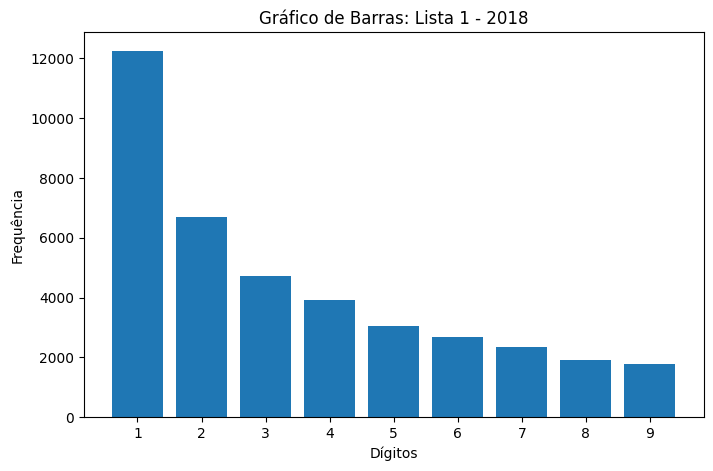

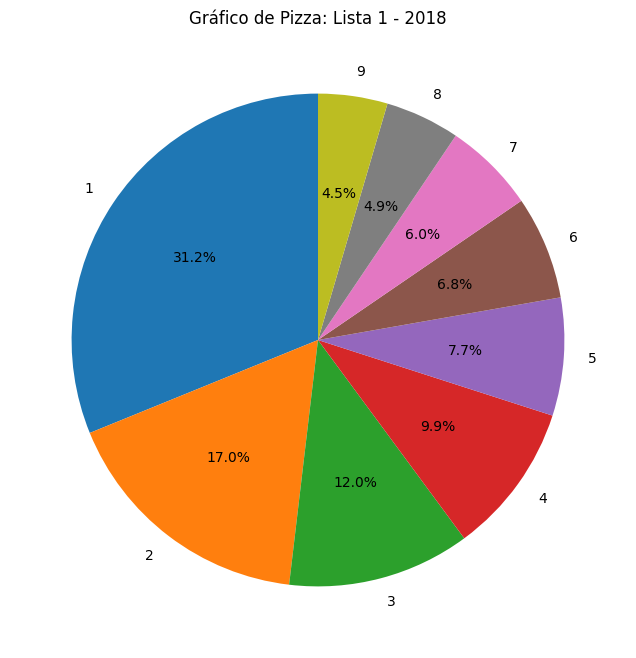

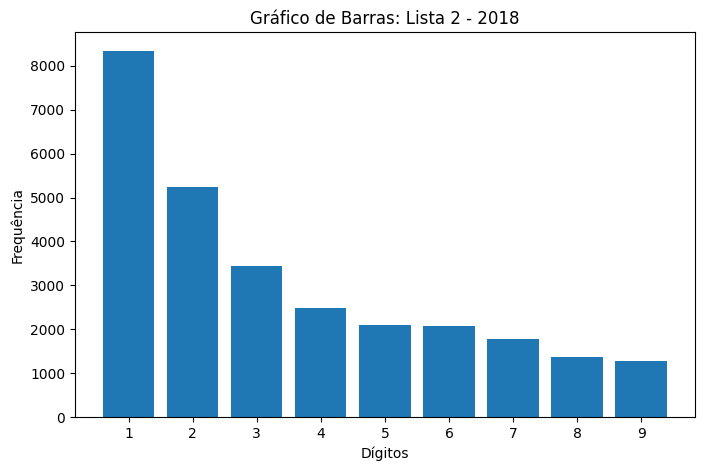

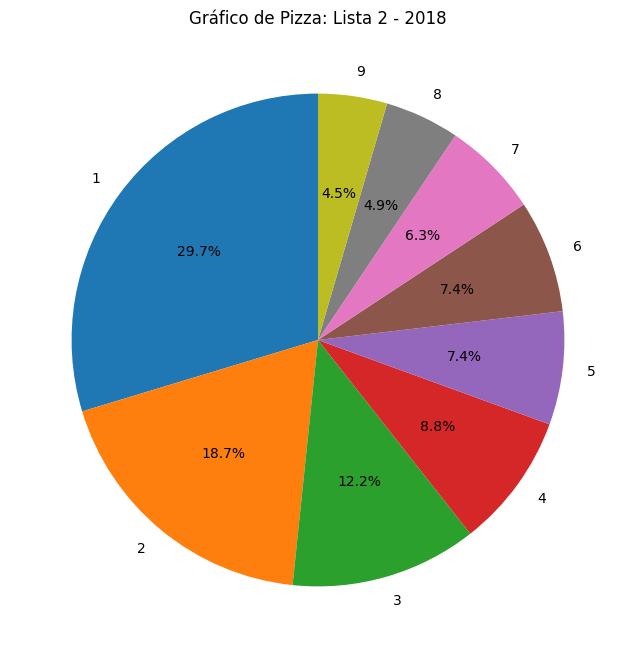

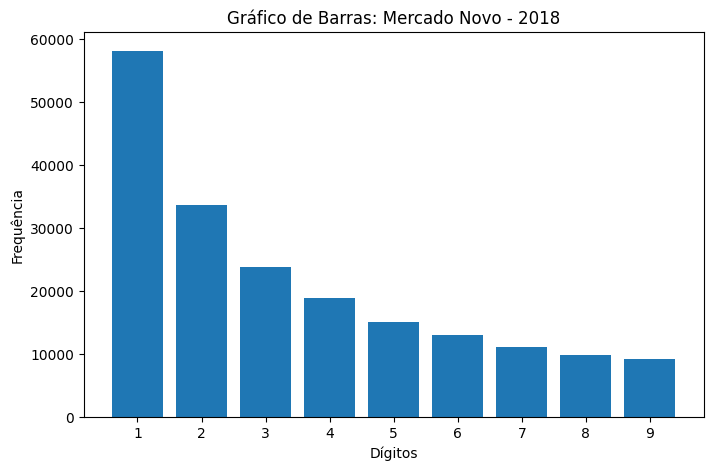

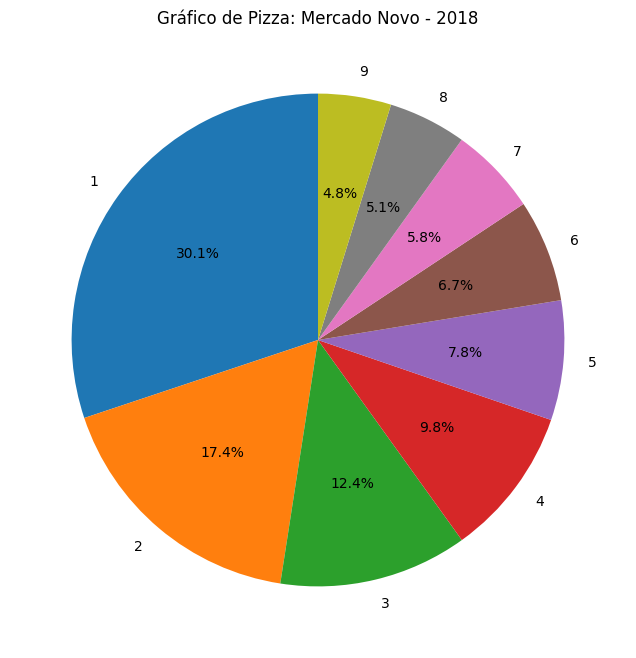

Analisando o ano 2019:


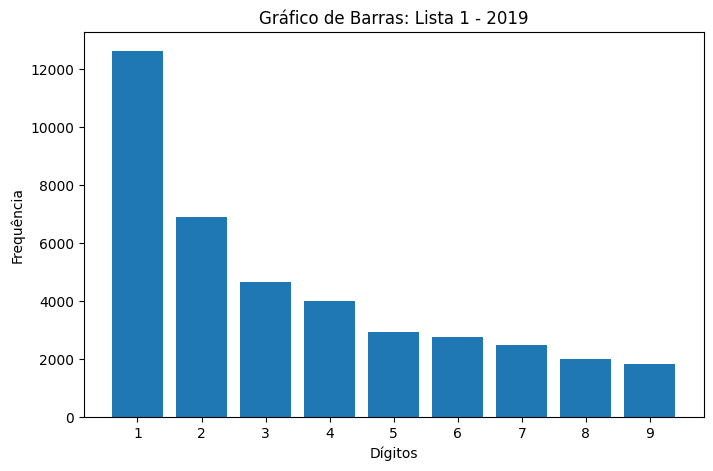

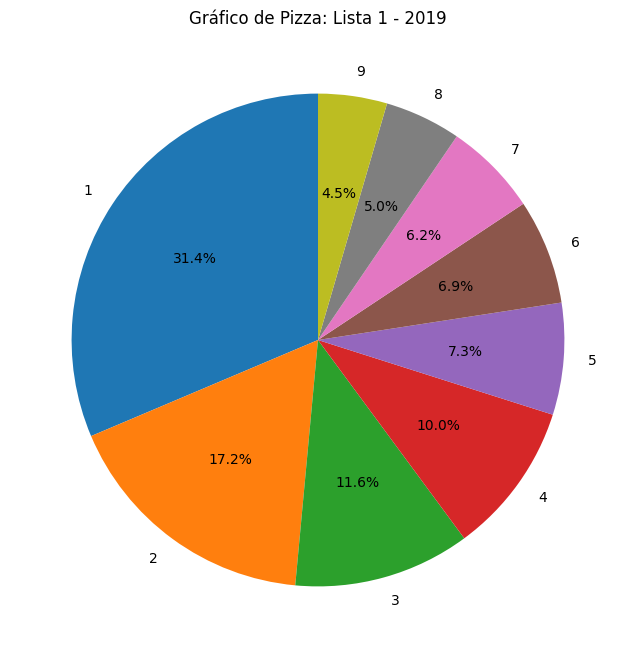

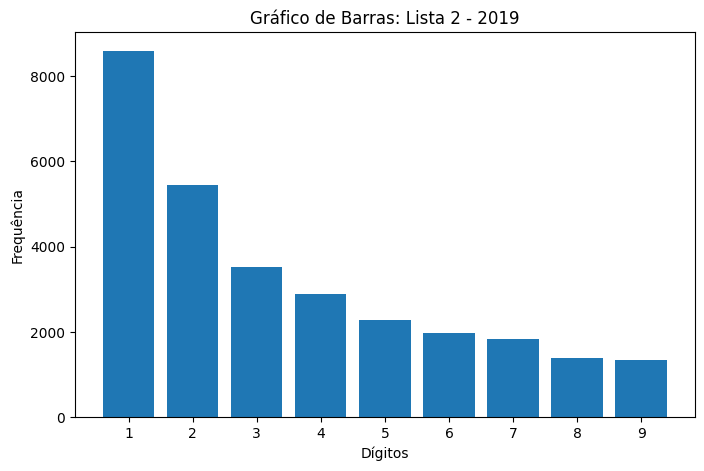

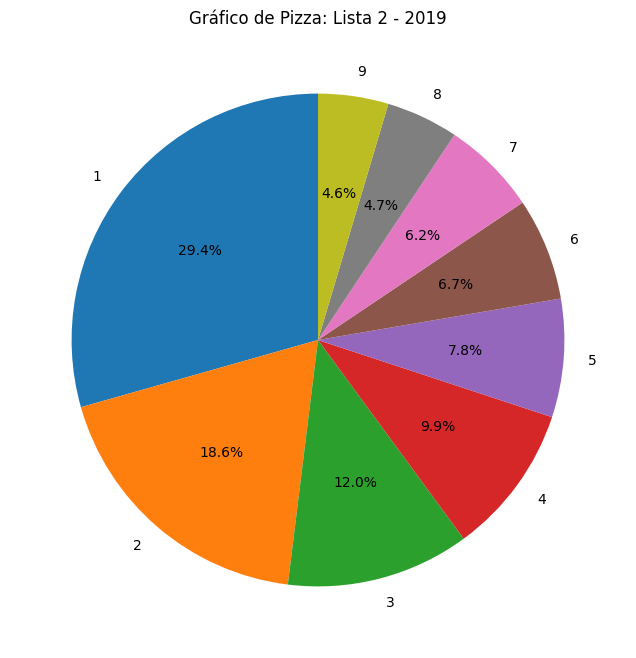

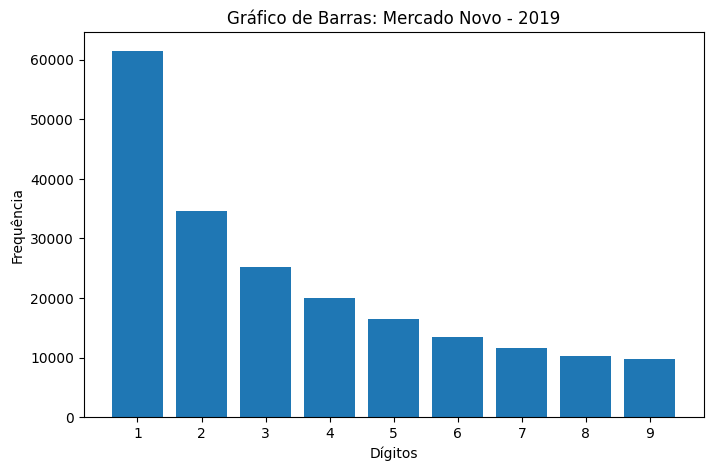

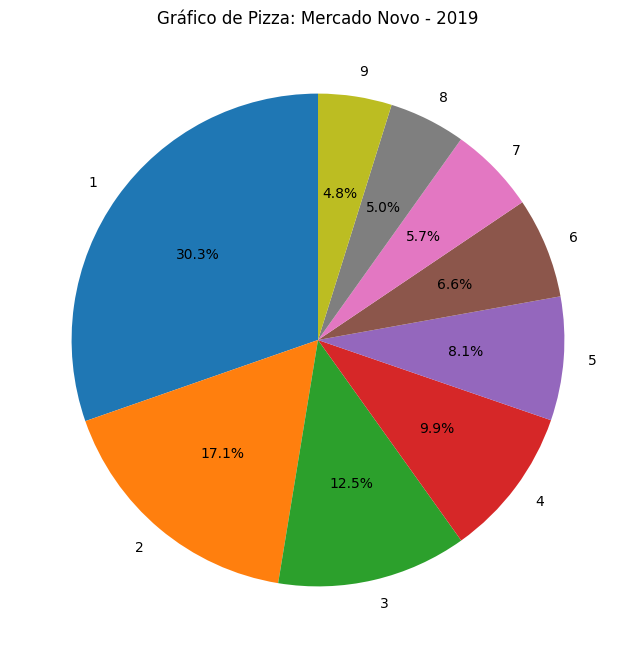

Analisando o ano 2020:


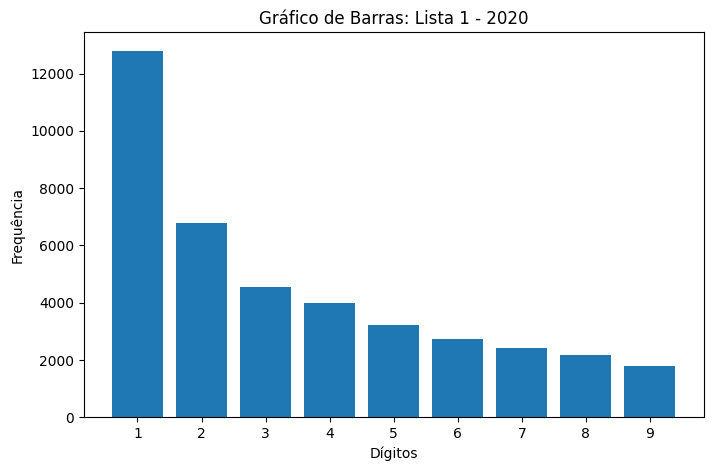

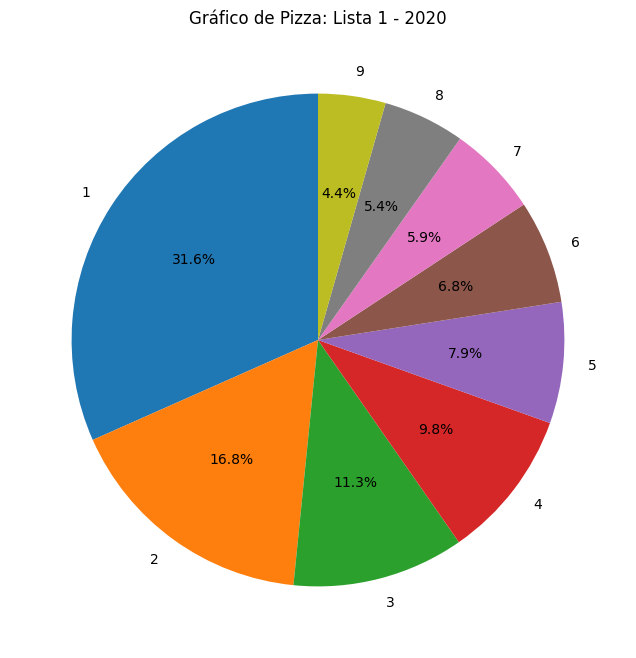

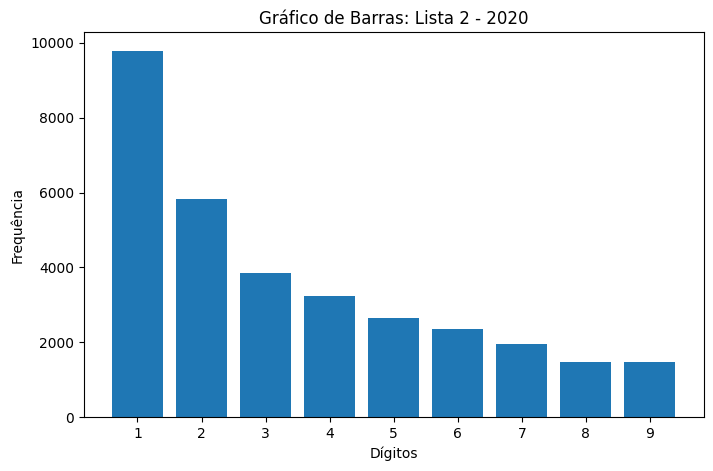

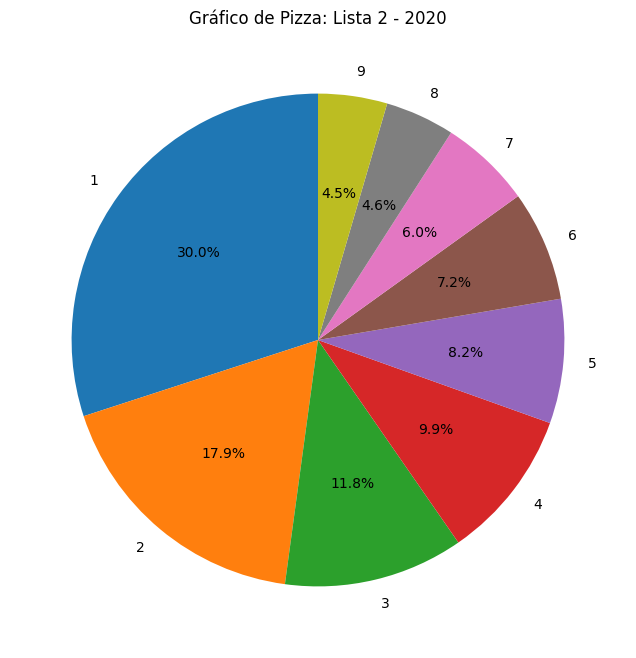

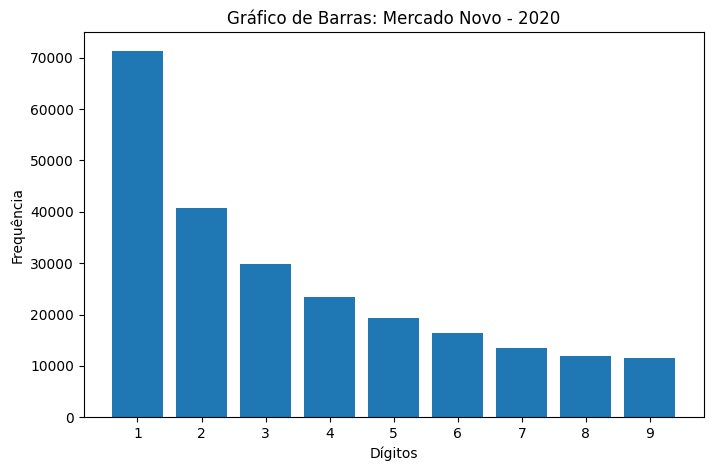

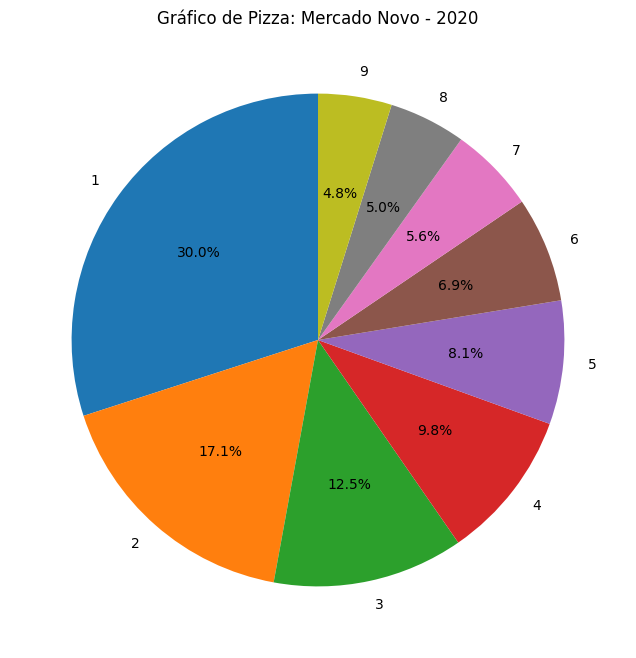

Analisando o ano 2021:


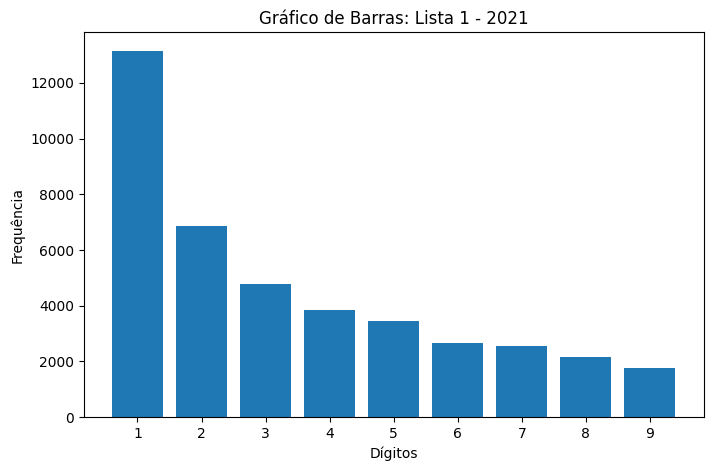

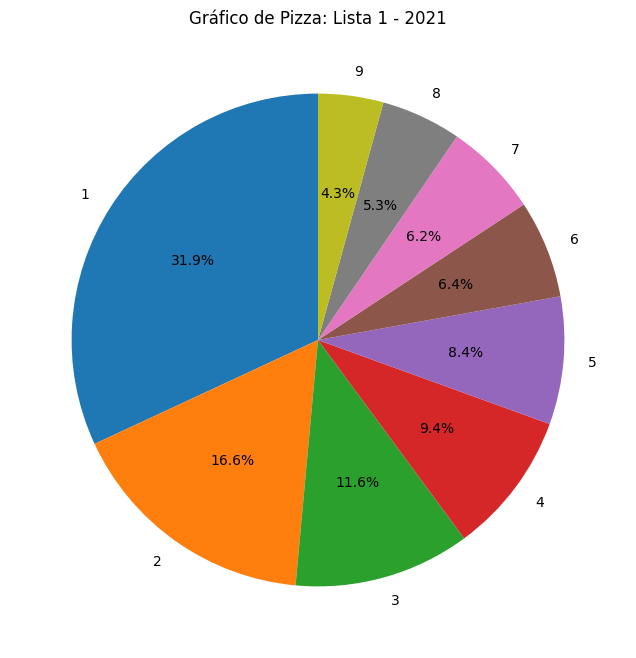

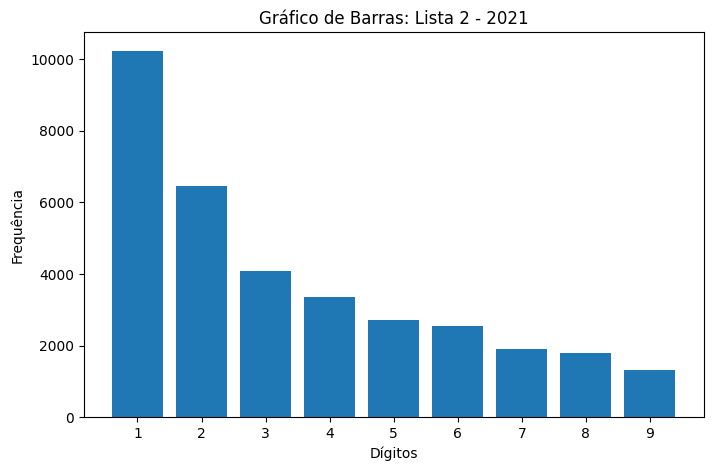

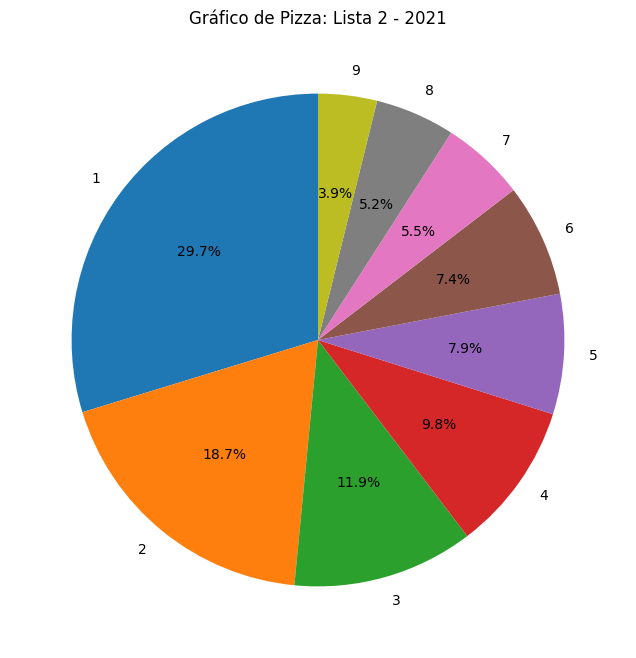

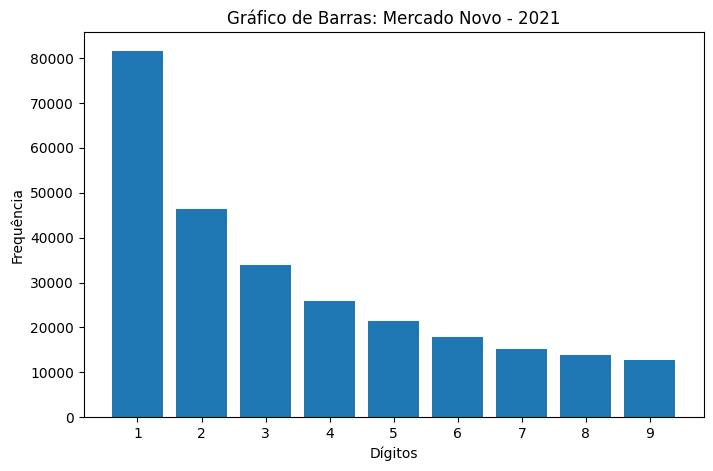

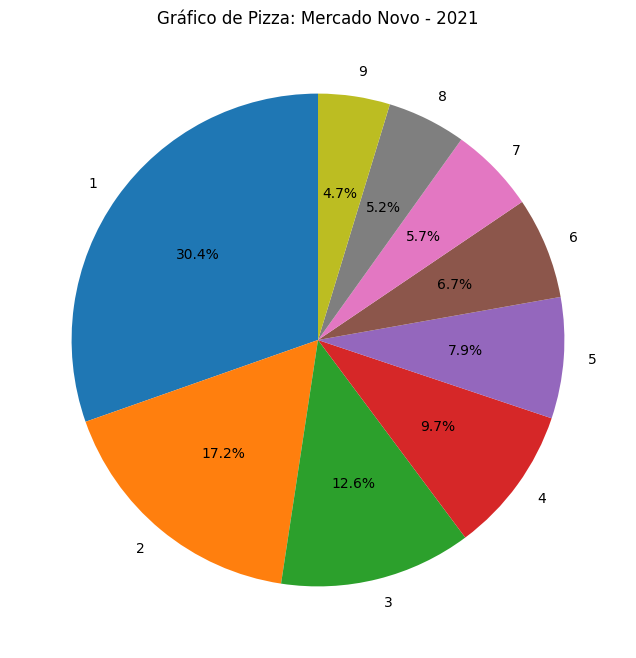

Analisando o ano 2022:


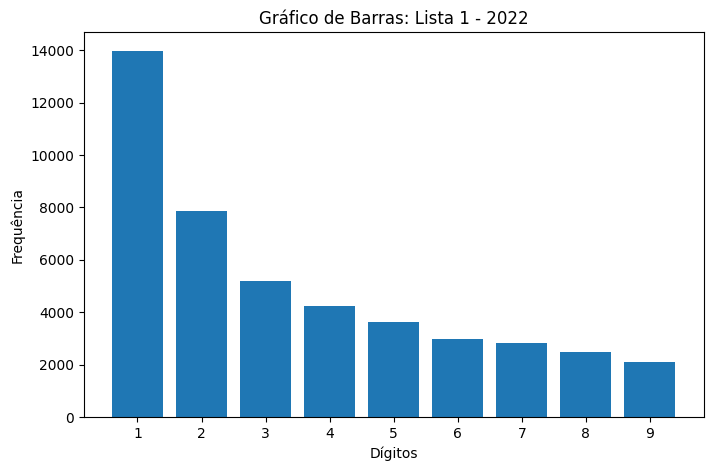

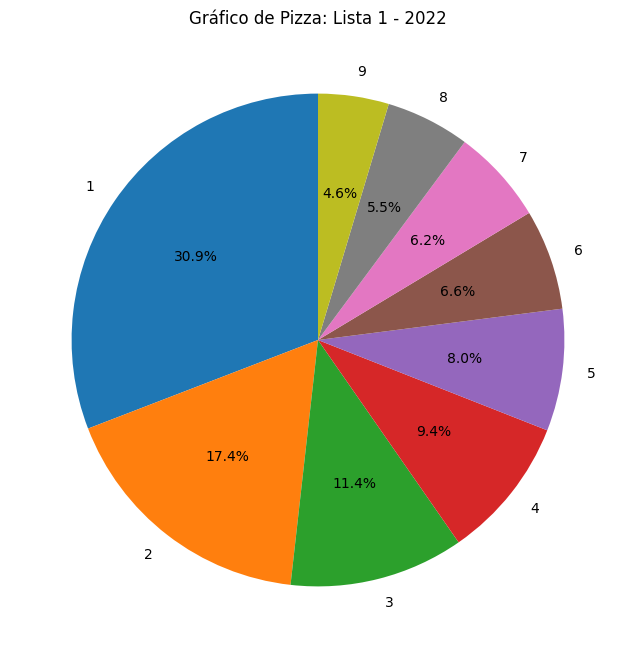

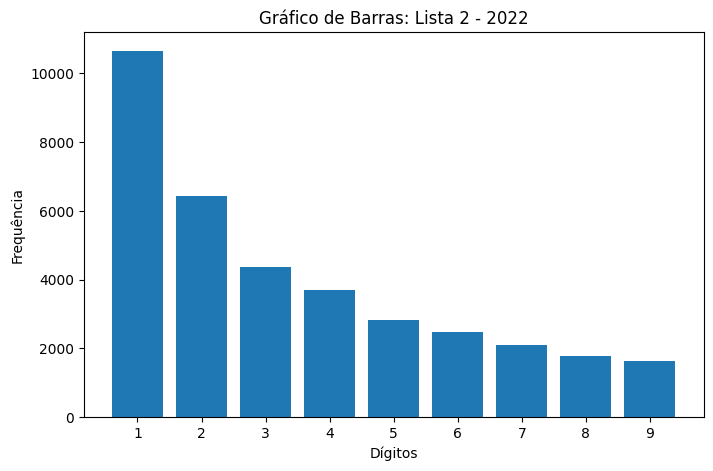

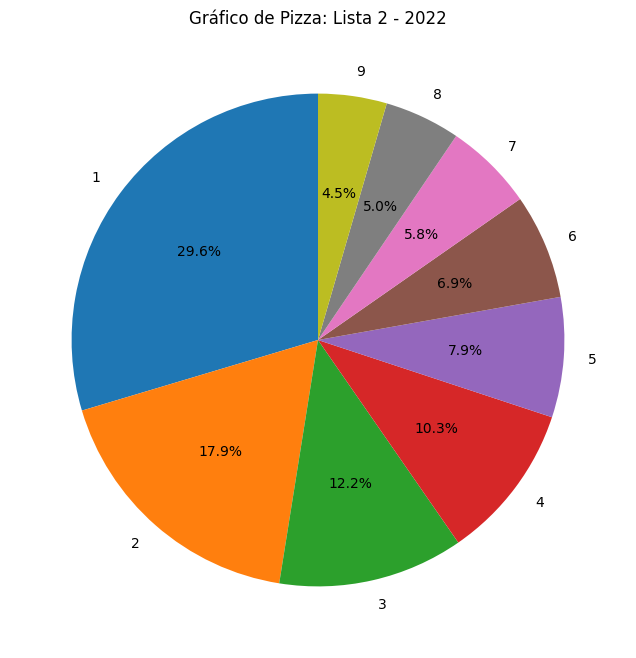

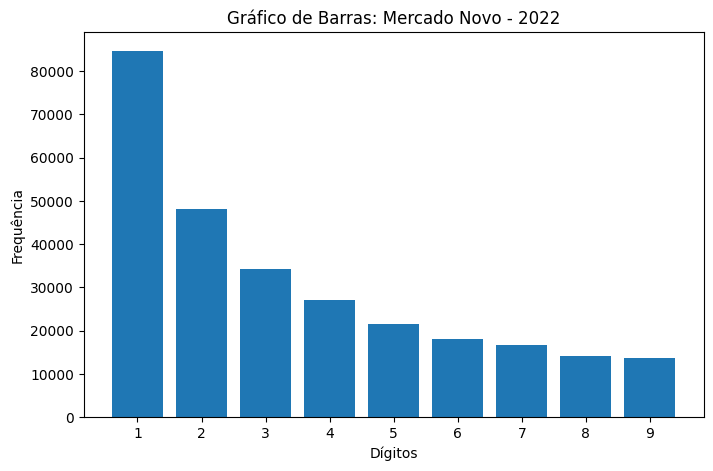

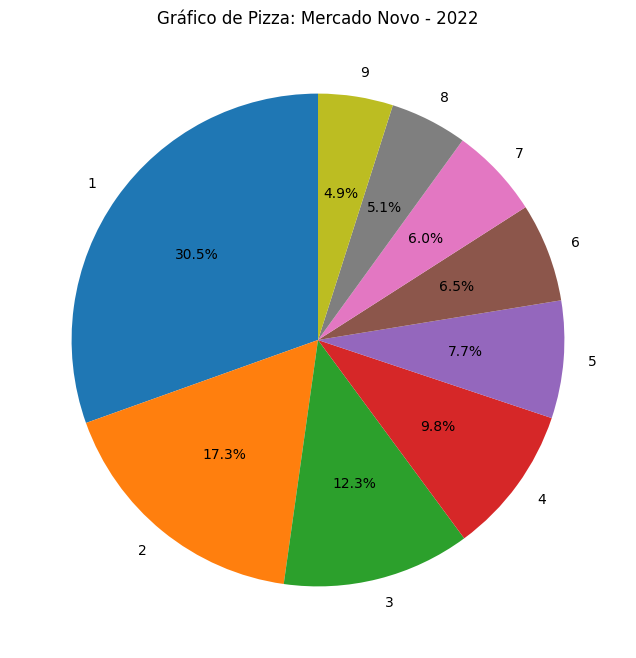

Analisando o ano 2023:


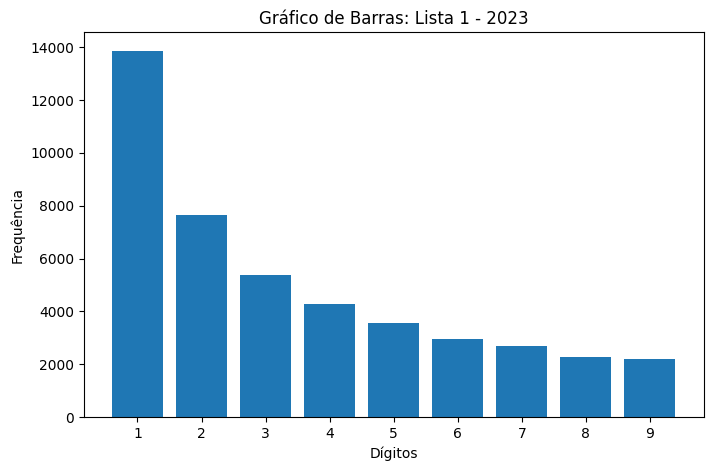

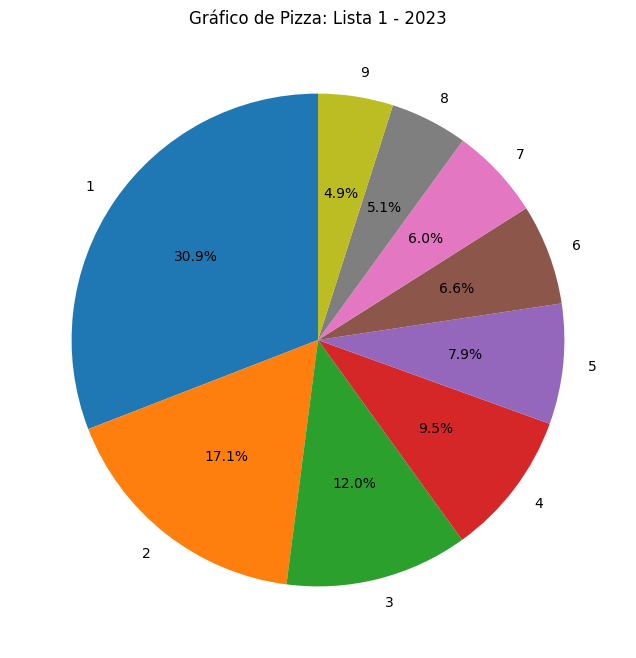

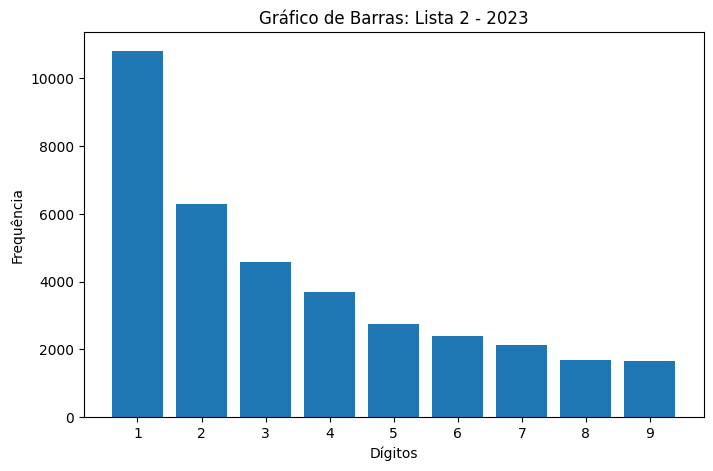

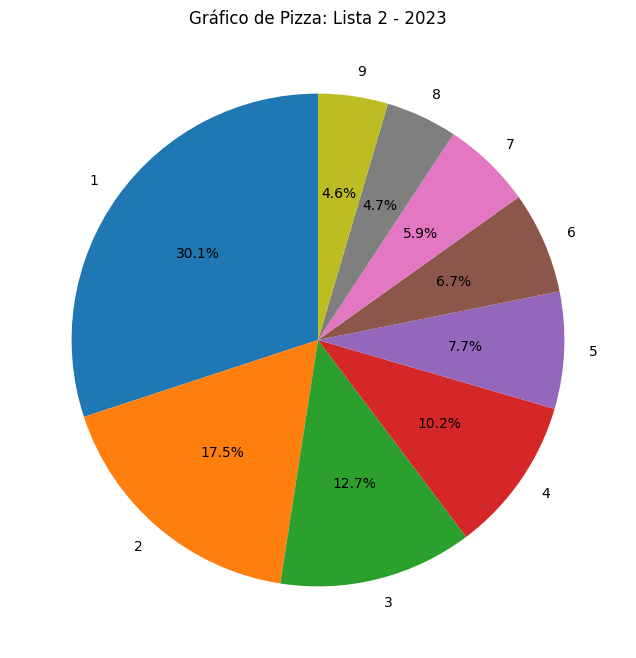

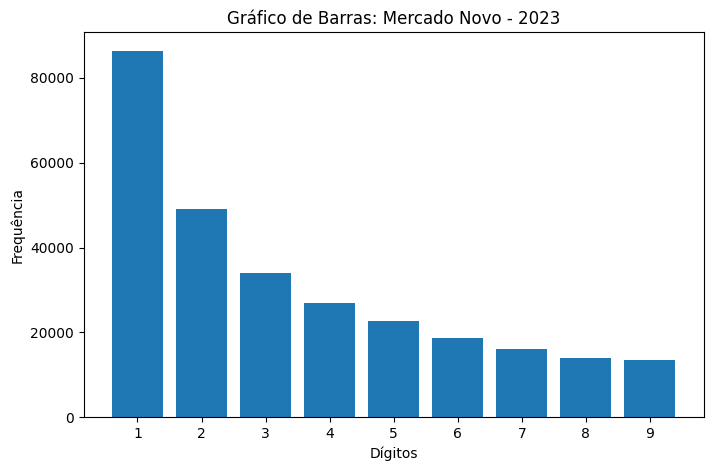

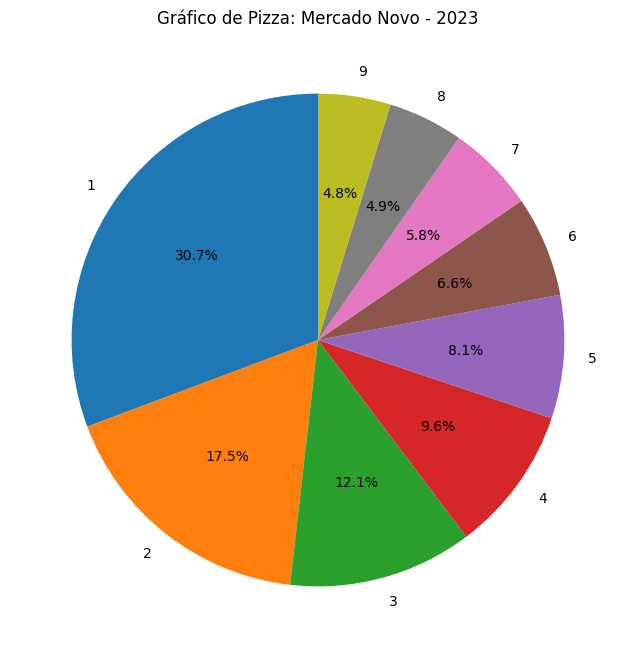

In [ ]:
import matplotlib.pyplot as plt

def ordenar_frequencias(frequencias):
    # Garantir que a ordem dos dígitos seja de 1 a 9
    digitos = [str(i) for i in range(1, 10)]
    frequencias_ordenadas = {d: frequencias.get(d, 0) for d in digitos}
    return frequencias_ordenadas

# Função para gerar gráficos de barra e pizza
def gerar_graficos(frequencias, titulo):
    # Ordenar as frequências
    frequencias_ordenadas = ordenar_frequencias(frequencias)

    # Gráfico de Barras
    plt.figure(figsize=(8, 5))
    plt.bar(frequencias_ordenadas.keys(), frequencias_ordenadas.values())
    plt.title(f"Gráfico de Barras: {titulo}")
    plt.xlabel("Dígitos")
    plt.ylabel("Frequência")
    plt.show()

    # Gráfico de Pizza
    plt.figure(figsize=(8, 8))
    plt.pie(frequencias_ordenadas.values(), labels=frequencias_ordenadas.keys(), autopct='%1.1f%%', startangle=90)
    plt.title(f"Gráfico de Pizza: {titulo}")
    plt.show()

# Exemplo de uso nos DataFrames iterados
for year, df in dfs_by_year.items():
    print(f"Analisando o ano {year}:")

    # Calcular as frequências de primeiros dígitos para cada categoria
    frequencias_lista_1 = contar_digitos(df[df['codigo'] == 'nivel_1'])
    frequencias_lista_2 = contar_digitos(df[df['codigo'] == 'nivel_2'])
    frequencias_mercado_novo = contar_digitos(df[df['codigo'] == 'NovoMercado'])

    # Gerar gráficos para cada categoria
    gerar_graficos(frequencias_lista_1, f"Lista 1 - {year}")
    gerar_graficos(frequencias_lista_2, f"Lista 2 - {year}")
    gerar_graficos(frequencias_mercado_novo, f"Mercado Novo - {year}")

Já as americanas não podemos concluir da mesma forma. Portanto podemos afirmar que a fraude nas Lo9jas Americanas podendo ser desconfiado de fraudular as demonstrações financeiras tanto anuais como trimestrais

In [ ]:
americanas = {"AMERICANAS S.A": "AMER"}
dfs_americanas=[]
for year, df in dfs_by_year.items():
    found = False
    for denom, code in americanas.items():
        # Verificar se o valor de 'DENOM_CIA' contém a chave ou o valor no dicionário
        if df['DENOM_CIA'].str.contains(denom, case=False).any():
            df_americanas = df[df['DENOM_CIA'].str.contains(denom, case=False)]
            valores_conta = df_americanas['VL_CONTA'].dropna()
            found = True
            dfs_americanas.append(df_americanas)
        elif df['DENOM_CIA'].str.contains(code, case=False).any():
            df_americanas = df[df['DENOM_CIA'].str.contains(code, case=False)]
            valores_conta = df_americanas['VL_CONTA'].dropna()
            found = True
            dfs_americanas.append(df_americanas)

    if not found:
        print(f"Nenhum dado encontrado para o ano {year}")

In [ ]:
from collections import Counter

def contar_digitos(df):
    # Contar o primeiro dígito de cada valor na coluna 'VL_CONTA', excluindo valores que começam com '0'
    primeiros_digitos = [str(num)[0] for num in df['VL_CONTA'] if str(num).isdigit() and str(num)[0] != '0']

    # Contar a frequência de cada primeiro dígito
    frequencias = Counter(primeiros_digitos)

    return frequencias

# Dicionário para armazenar as contagens por ano
count_by_year = {}

# Supondo que 'dfs_by_year' contém os DataFrames por ano (de 2018 a 2023)
for year, df in dfs_by_year.items():
    # Verifica se o DataFrame contém dados da Americanas
    df_americanas = df[df['DENOM_CIA'].str.contains('AMERICANAS', case=False)]

    if not df_americanas.empty:
        # Contar os dígitos para o ano específico
        am = contar_digitos(df_americanas)
        # Armazenar o contador de dígitos no dicionário usando o ano como chave
        count_by_year[year] = am
        # Exibir a contagem de dígitos para o ano atual
        print(f"Contagem de dígitos para {year}: {am}")

# Exibir o total de contagens por ano
print("Contagem total de dígitos por ano (2018-2023):")
for year, count in count_by_year.items():
    print(f"Ano {year}: {count}")

Contagem de dígitos para 2018: Counter({'1': 983, '2': 699, '3': 525, '4': 446, '5': 367, '6': 200, '8': 157, '7': 153, '9': 121})
Contagem de dígitos para 2019: Counter({'1': 976, '3': 618, '2': 605, '4': 428, '5': 408, '6': 296, '7': 219, '8': 188, '9': 151})
Contagem de dígitos para 2020: Counter({'1': 961, '2': 660, '3': 545, '4': 438, '5': 411, '6': 293, '8': 225, '7': 216, '9': 161})
Contagem de dígitos para 2021: Counter({'1': 1177, '2': 633, '3': 520, '4': 507, '5': 332, '6': 296, '8': 243, '7': 230, '9': 185})
Contagem de dígitos para 2022: Counter({'1': 716, '2': 338, '4': 258, '3': 213, '5': 175, '7': 160, '8': 144, '6': 128, '9': 90})
Contagem de dígitos para 2023: Counter({'1': 630, '2': 271, '3': 230, '5': 195, '4': 186, '8': 106, '6': 94, '9': 83, '7': 56})
Contagem total de dígitos por ano (2018-2023):
Ano 2018: Counter({'1': 983, '2': 699, '3': 525, '4': 446, '5': 367, '6': 200, '8': 157, '7': 153, '9': 121})
Ano 2019: Counter({'1': 976, '3': 618, '2': 605, '4': 428, '

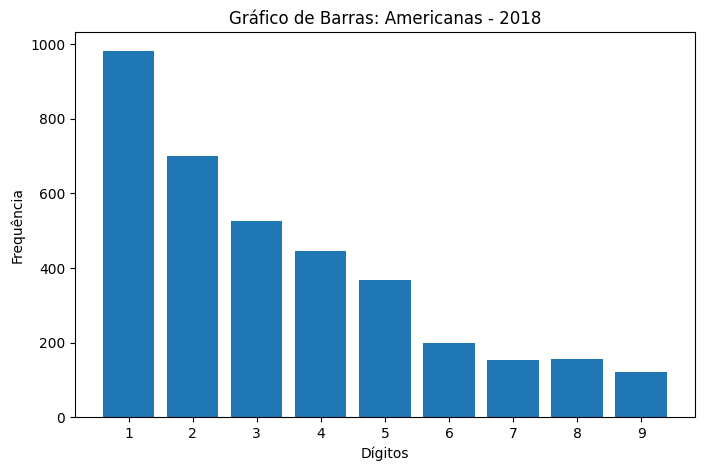

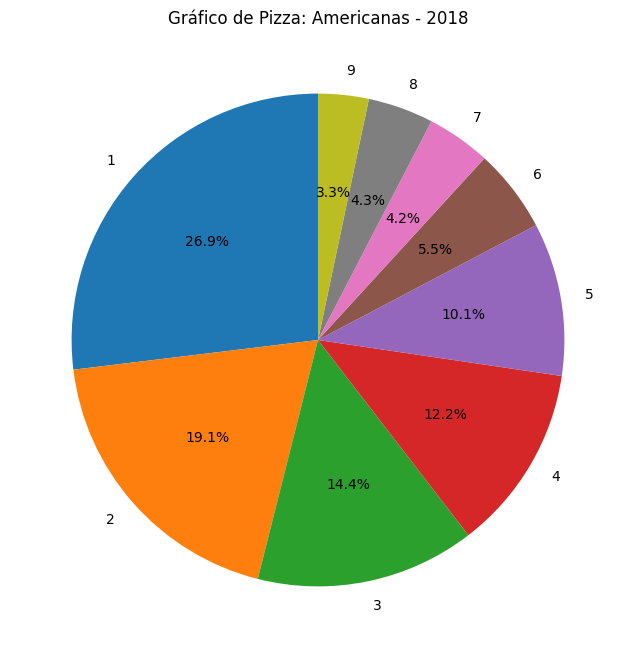

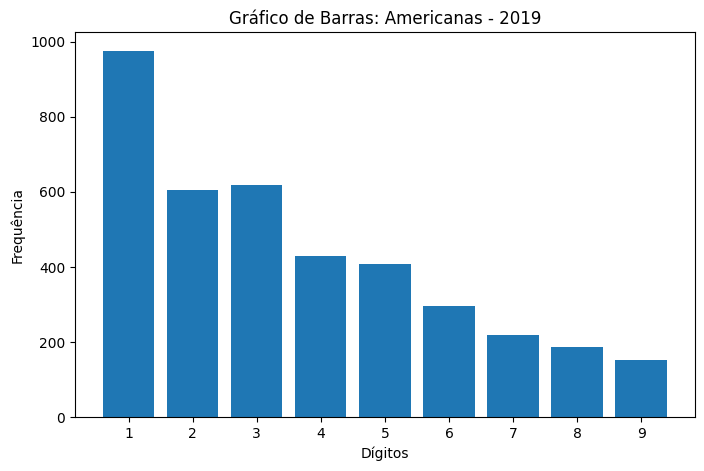

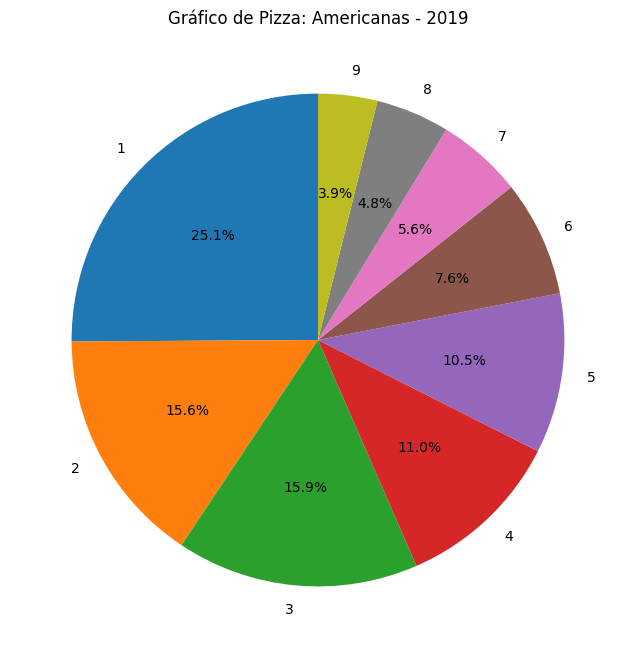

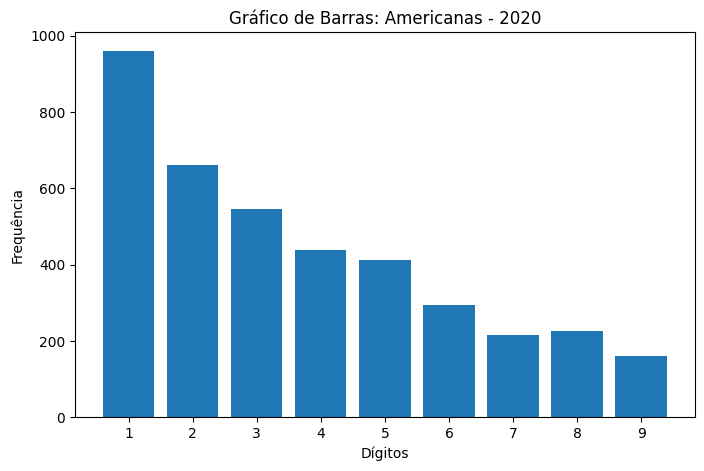

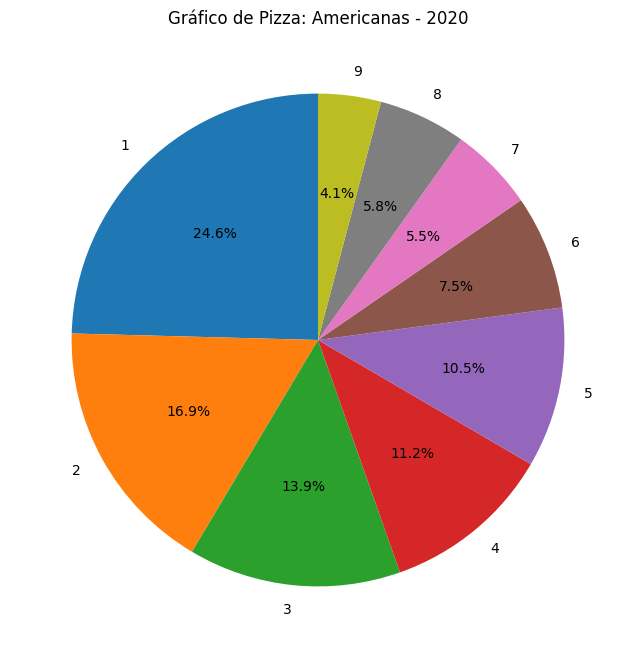

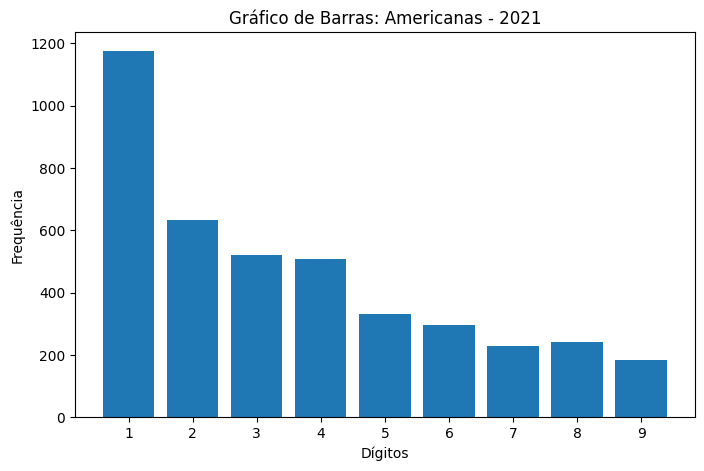

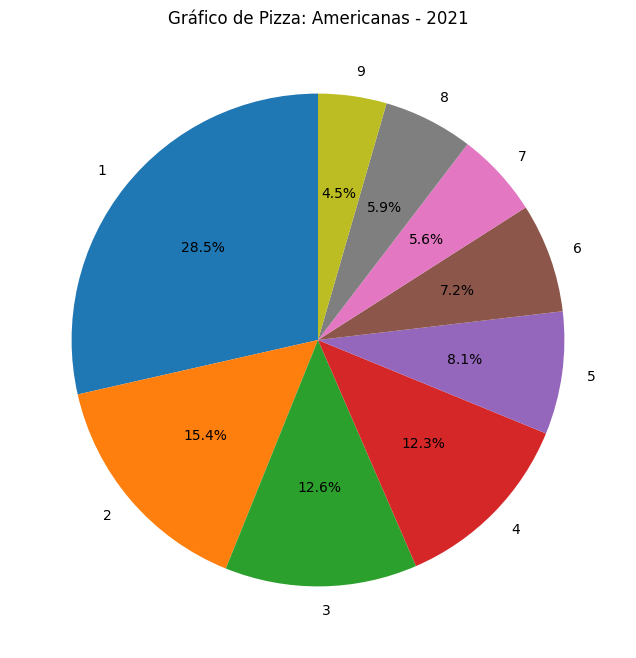

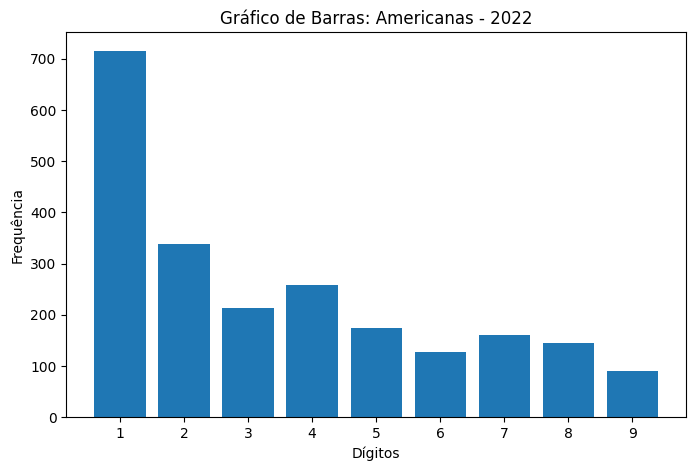

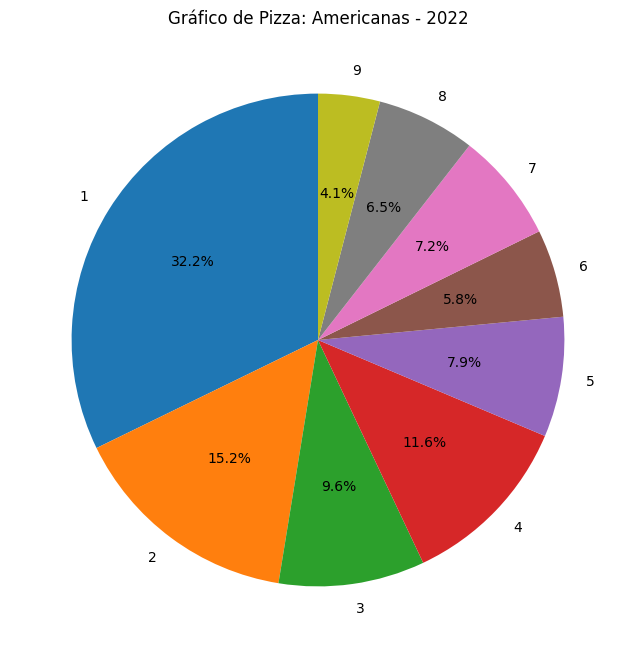

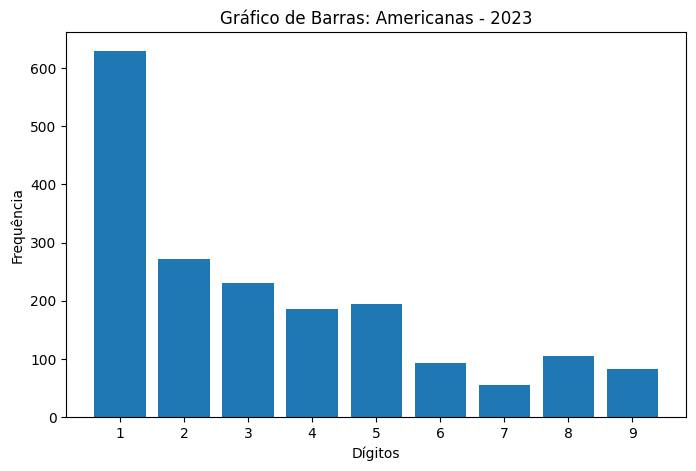

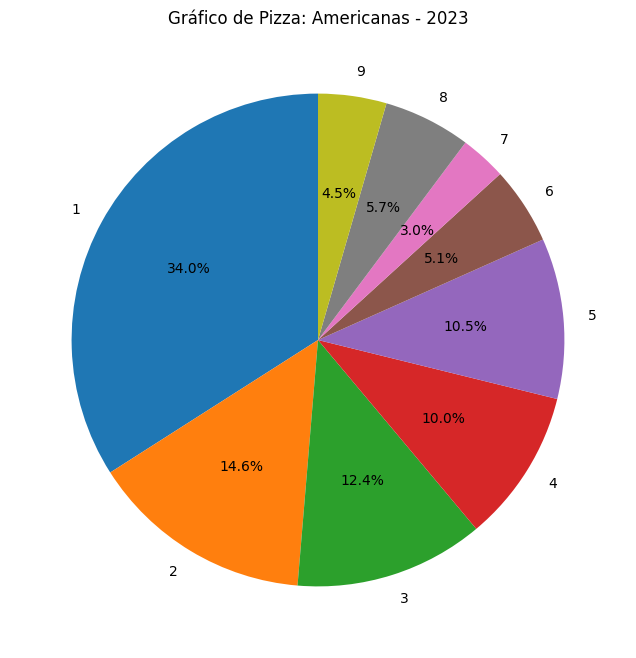

In [ ]:
import matplotlib.pyplot as plt

# Função para garantir a ordenação das frequências (1 a 9)
def ordenar_frequencias(frequencias):
    digitos = [str(i) for i in range(1, 10)]
    frequencias_ordenadas = {d: frequencias.get(d, 0) for d in digitos}
    return frequencias_ordenadas

# Função para gerar gráficos de barra e pizza
def gerar_graficos(frequencias, titulo):
    # Ordenar as frequências
    frequencias_ordenadas = ordenar_frequencias(frequencias)

    # Gráfico de Barras
    plt.figure(figsize=(8, 5))
    plt.bar(frequencias_ordenadas.keys(), frequencias_ordenadas.values())
    plt.title(f"Gráfico de Barras: {titulo}")
    plt.xlabel("Dígitos")
    plt.ylabel("Frequência")
    plt.show()

    # Gráfico de Pizza
    plt.figure(figsize=(8, 8))
    plt.pie(frequencias_ordenadas.values(), labels=frequencias_ordenadas.keys(), autopct='%1.1f%%', startangle=90)
    plt.title(f"Gráfico de Pizza: {titulo}")
    plt.show()

# Iterar sobre o dicionário count_by_year e gerar gráficos para cada ano
for year, frequencias in count_by_year.items():
    gerar_graficos(frequencias, f"Americanas - {year}")

